In [6]:
import pandas as pd
import matplotlib.pyplot as plt

hosp_df = pd.read_parquet(
    "auxiliary-data/rsv/rsv-net/2026-03-18_weekly_rates_lab_confirmed_rsv_hosp.parquet"
)

In [7]:
hosp_df.head()

,State,Season,Week ending date,Age Category,Sex,Race,Rate,Cumulative Rate,Type
0,Utah,2022-23,2023-09-30,0-17 years (Children),All,Hispanic,0.0,300.2,Crude Rate
1,Utah,2022-23,2023-09-23,0-17 years (Children),All,Hispanic,0.0,300.2,Crude Rate
2,Utah,2022-23,2023-09-16,0-17 years (Children),All,Hispanic,0.0,300.2,Crude Rate
3,Utah,2022-23,2023-09-09,0-17 years (Children),All,Hispanic,0.0,300.2,Crude Rate
4,Utah,2022-23,2023-09-02,0-17 years (Children),All,Hispanic,1.3,300.2,Crude Rate


In [8]:
num_states = len(hosp_df['State'].unique())
print(f"Available state data: {hosp_df['State'].unique()}")

Available state data: <StringArray>
[          'Utah',      'Tennessee',         'Oregon',       'New York',
     'New Mexico',      'Minnesota',       'Michigan',       'Maryland',
        'Georgia',    'Connecticut',       'Colorado',     'California',
        'RSV-NET', 'North Carolina',     'Washington']
Length: 15, dtype: string


In [9]:
children_data = hosp_df.loc[
    (hosp_df["Age Category"] == "0-17 years (Children)")
    & (hosp_df['Sex'] == 'All') & (hosp_df['Race'] == 'All')
].drop(["Cumulative Rate","Race","Sex","Age Category"],axis = 1)

children_data.loc[(children_data['State'] == 'Utah') & (children_data['Season'] == '2021-22')]

,State,Season,Week ending date,Rate,Type
106132,Utah,2021-22,2021-10-09,3.6,Crude Rate
106133,Utah,2021-22,2021-10-16,5.9,Crude Rate
106134,Utah,2021-22,2021-10-23,10.4,Crude Rate
106135,Utah,2021-22,2021-10-30,7.5,Crude Rate
106136,Utah,2021-22,2021-11-06,12.1,Crude Rate
106137,Utah,2021-22,2021-11-13,8.1,Crude Rate
106138,Utah,2021-22,2021-11-20,9.4,Crude Rate
106139,Utah,2021-22,2021-11-27,12.4,Crude Rate
106140,Utah,2021-22,2021-12-04,13.4,Crude Rate
106141,Utah,2021-22,2021-12-11,14.0,Crude Rate


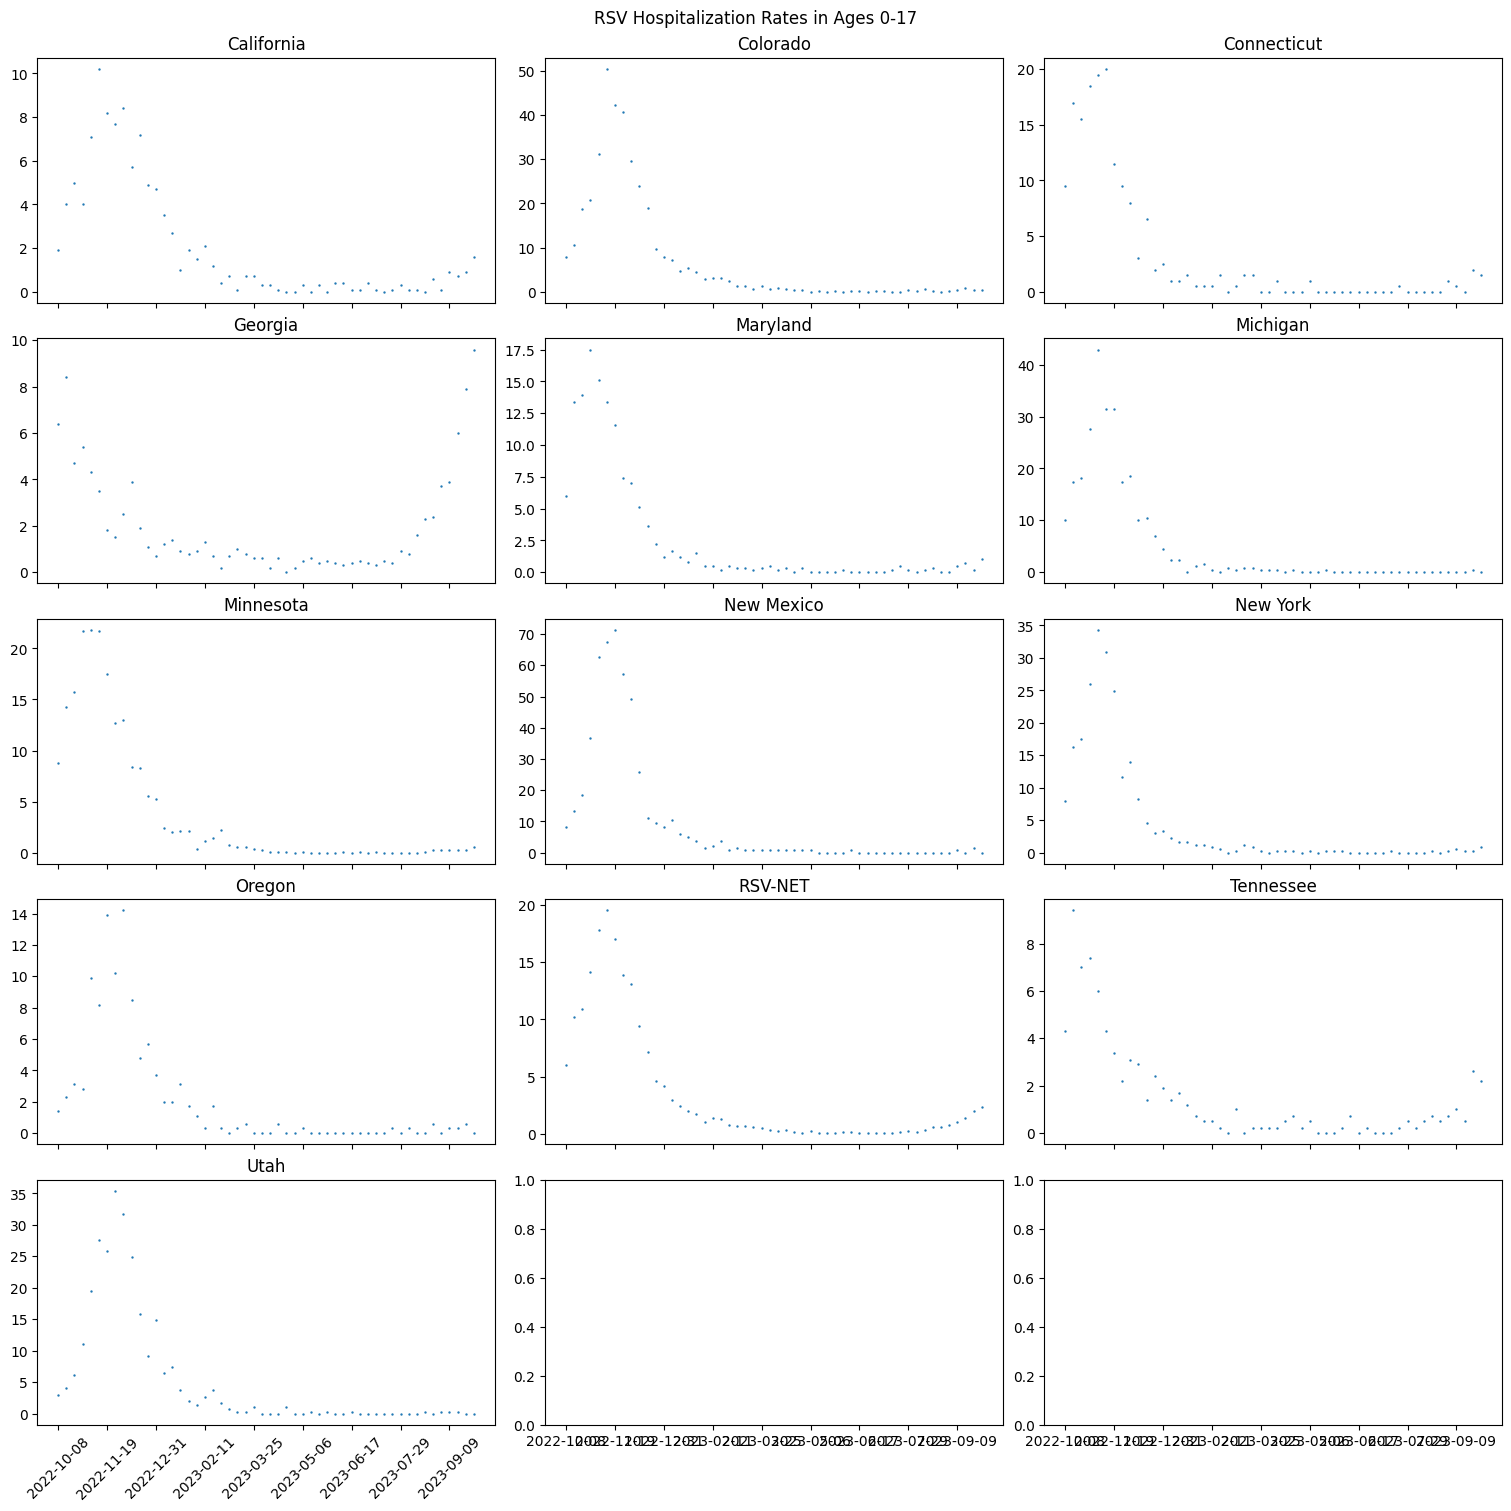

In [ ]:
import math
import matplotlib.ticker as ticker

ncols = 3

nrows = math.ceil(num_states / ncols)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 5, nrows * 3),
    sharex=True,
    layout="constrained",
)

axes = axes.flatten()

season = "2022-23"

fig.suptitle("RSV Hospitalization Rates in Ages 0-17")
for (group_name, gdf), ax in zip(
    children_data.loc[children_data["Season"] == season].groupby("State"), axes
):
    gdf = gdf.sort_values('Week ending date')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
    ax.tick_params(axis="x", labelrotation=45)
    ax.set_title(f"{group_name}")
    ax.scatter(gdf["Week ending date"], gdf["Rate"],s = 0.5)
